<h4>Exploratory analysis of the dataset to understand its structure, distribution, image properties, and segmentation masks before preprocessing and model training.</h4>

In [108]:
import os
import numpy as np
from PIL import Image 
import pandas as pd
from matplotlib import pyplot as plt 
from collections import Counter

In [109]:
PATH_BRAIN_DATA = "../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data"
PATH_BREAST_DATA= "../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

In [110]:
def list_dir(path, deep=0) : 
    if os.path.isdir(path) : 
        dir = path.split("/")[-1]
        print("|    "*deep, end="")
        print(dir)
        for file in os.listdir(path) :
            list_dir(os.path.join(path, file), deep=deep+1)

In [111]:
list_dir(PATH_BRAIN_DATA)
list_dir(PATH_BREAST_DATA)

data
|    masks
|    images
Dataset_BUSI_with_GT
|    malignant
|    normal
|    benign


In [112]:
paths_images = set()
def info_data(path) : 
    def info(images):
        nb_images = len(images)
        if nb_images < 1: 
            return
               
        elif nb_images < 10 : 
            print("Folder :", path)
            print(images )
        elif nb_images > 10 :
            print("Folder :", path)
            print(images[:10])

        print("Number of images:", nb_images)
        print("Types images:", set([img.split(".")[-1] for img in images]))
        sizes = list(set([np.shape(Image.open(os.path.join(path,img))) for img in images]))
        if len(sizes) < 10: 
            print("Size images:", sizes)
        else :
            print("Size images:", sizes[:10])
        paths_images.add(path)

        print("")

    image_extensions = {'png', 'jpg', 'jpeg', 'bmp', 'tiff', 'gif'}
    images_name = []
    files = os.listdir(path)
    for file in files : 
        file = os.path.join(path, file)
        if os.path.isdir(file):
            info_data(file)
        elif file.split(".")[-1].lower() in image_extensions :
            images_name.append(file.split("/")[-1])
    info(images_name)
        
    

In [113]:
info_data(PATH_BRAIN_DATA)

Folder : ../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data/masks
['362.png', '2393.png', '2395.png', '174.png', '2432.png', '1476.png', '1908.png', '1022.png', '1065.png', '1468.png']
Number of images: 3064
Types images: {'png'}
Size images: [(512, 512), (256, 256)]

Folder : ../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data/images
['362.png', '2393.png', '2395.png', '174.png', '2432.png', '1476.png', '1908.png', '1022.png', '1065.png', '1468.png']
Number of images: 3064
Types images: {'png'}
Size images: [(512, 512), (256, 256)]



In [114]:
info_data(PATH_BREAST_DATA)

Folder : ../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant
['malignant (201).png', 'malignant (101).png', 'malignant (160).png', 'malignant (109)_mask.png', 'malignant (5).png', 'malignant (90).png', 'malignant (150).png', 'malignant (93)_mask.png', 'malignant (21).png', 'malignant (176).png']
Number of images: 421
Types images: {'png'}


Size images: [(393, 468, 3), (581, 617, 3), (478, 557, 3), (470, 421), (471, 673), (335, 190, 3), (473, 426), (492, 552, 3), (463, 556, 3), (434, 611)]

Folder : ../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal
['normal (71)_mask.png', 'normal (55).png', 'normal (56).png', 'normal (41).png', 'normal (121)_mask.png', 'normal (22)_mask.png', 'normal (93).png', 'normal (89)_mask.png', 'normal (28)_mask.png', 'normal (16)_mask.png']
Number of images: 266
Types images: {'png'}
Size images: [(619, 763, 3), (470, 558, 3), (493, 545, 3), (474, 509, 3), (492, 554, 3), (707, 804, 3), (471, 703, 3), (490, 548, 3), (469, 552, 3), (468, 558, 3)]

Folder : ../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign
['benign (421)_mask.png', 'benign (145).png', 'benign (422).png', 'benign (372).png', 'benign (275)_mask.png', 'benign (340)_mask.png', 'benign (245).png', 'benign (30).png', 'benign (18).png', 'benign (179)_mask.png']
Number of images: 891
Types image

The analysis shows that all datasets use PNG images, but their dimensions vary significantly. The brain tumor dataset contains 3,064 images and masks, with dimensions of either 512×512 or 256×256. The breast ultrasound dataset contains 421 malignant, 266 normal, and 891 benign images, with different image sizes and both grayscale and RGB images. Therefore, resizing and channel normalization will be required during preprocessing to ensure a consistent input format for the segmentation model.


In [115]:
paths_images = list(paths_images)
paths_images

['../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign',
 '../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal',
 '../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data/images',
 '../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data/masks',
 '../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant']

In [ ]:
def count_images_in_folder(folder_path):
    images = os.listdir(folder_path)
    print(f"Number of images in '{folder_path}': {len(images)}")
    return images

In [117]:
def count_images_and_masks(folder_path):
    files = os.listdir(folder_path)
    images = [f for f in files if '_mask' not in f.lower()]
    masks = [f for f in files if '_mask' in f.lower()]

    print(f"Number of images in '{folder_path}': {len(images)}")
    print(f"Number of images in'{folder_path}': {len(masks)}")

    return images, masks

In [118]:
data = {}
data["brain"] = {}
for path in paths_images : 
    if 'brain' not in path:
        images, masks = count_images_and_masks(path)
        data[path.split("/")[-1]] = {}
        data[path.split("/")[-1]]["images"] = images
        data[path.split("/")[-1]]["masks"] = masks
    else : 
        imgs = count_images_in_folder(path)
        data["brain"][path.split("/")[-1]] = imgs 


Number of images in '../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign': 437
Number of images in'../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign': 454
Number of images in '../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal': 133
Number of images in'../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal': 133
Number of images in '../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data/images': 3064
Number of images in '../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data/masks': 3064
Number of images in '../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant': 210
Number of images in'../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant': 211


The brain tumor dataset comprises 3,064 images and their corresponding 3,064 masks. The breast ultrasound dataset includes 133 images of normal cases, between 210 and 211 images of malignant tumors, and between 437 and 454 images of benign tumors; slight discrepancies between the image counts and mask counts necessitate verification prior to the preprocessing stage, as this implies that some images correspond to multiple masks.

In [119]:
def display_images(images_paths):

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))

    axes = axes.flatten()

    for ax, img_path in zip(axes, images_paths):

        img = Image.open(img_path)

        ax.imshow(img)
        ax.set_title(img_path.split("/")[-1])
        ax.axis("off")

    # Cacher les axes inutilisés
    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("")

images  for: brain :


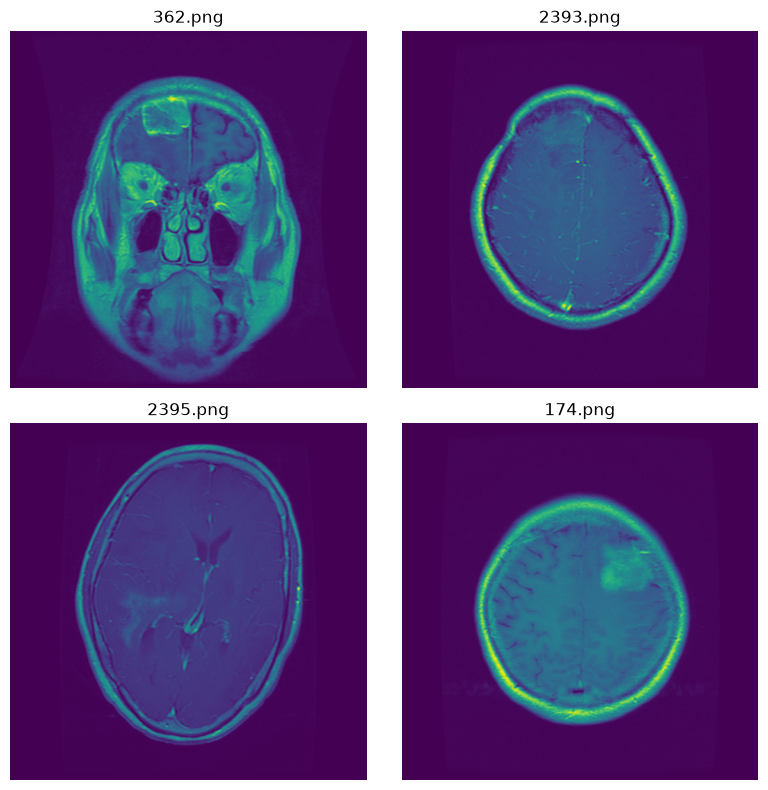


masks  for: brain :


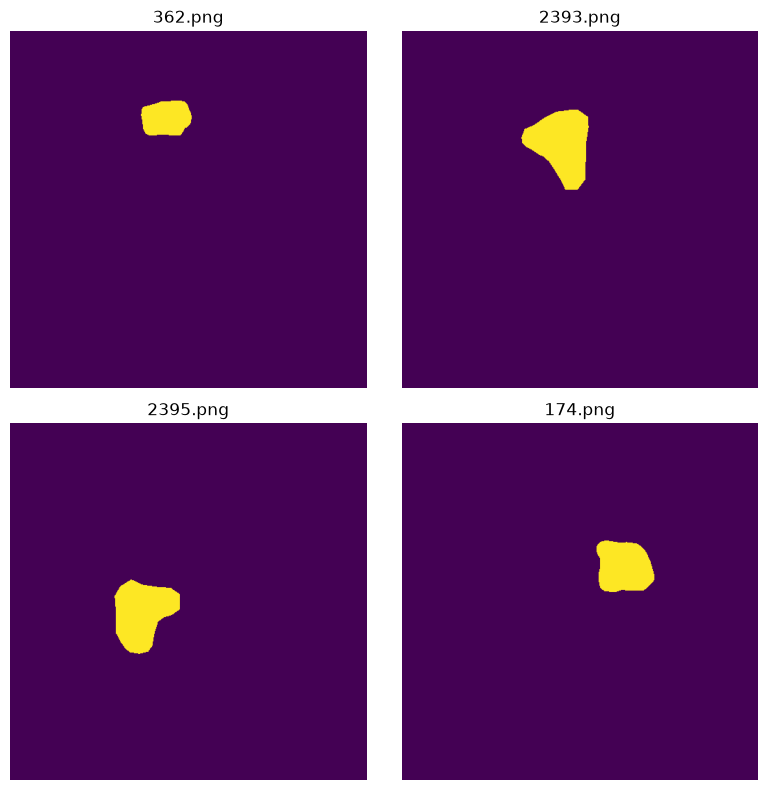


images  for: benign :


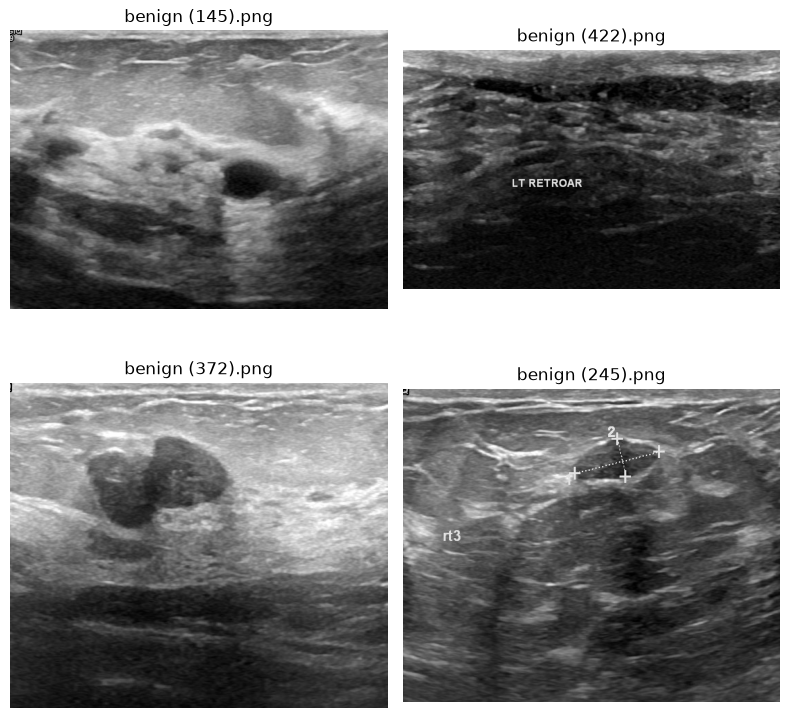


masks  for: benign :


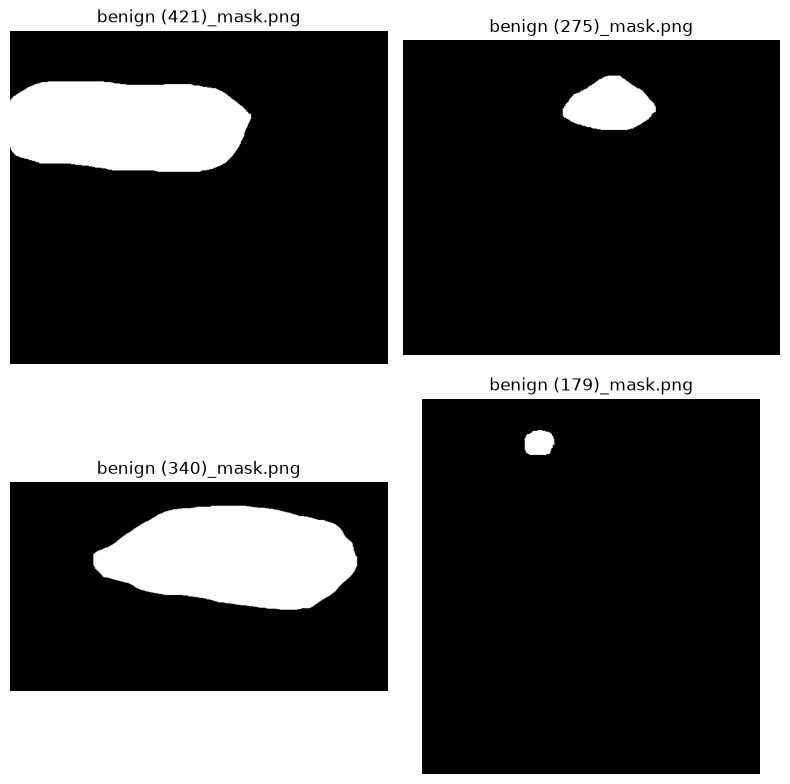


images  for: normal :


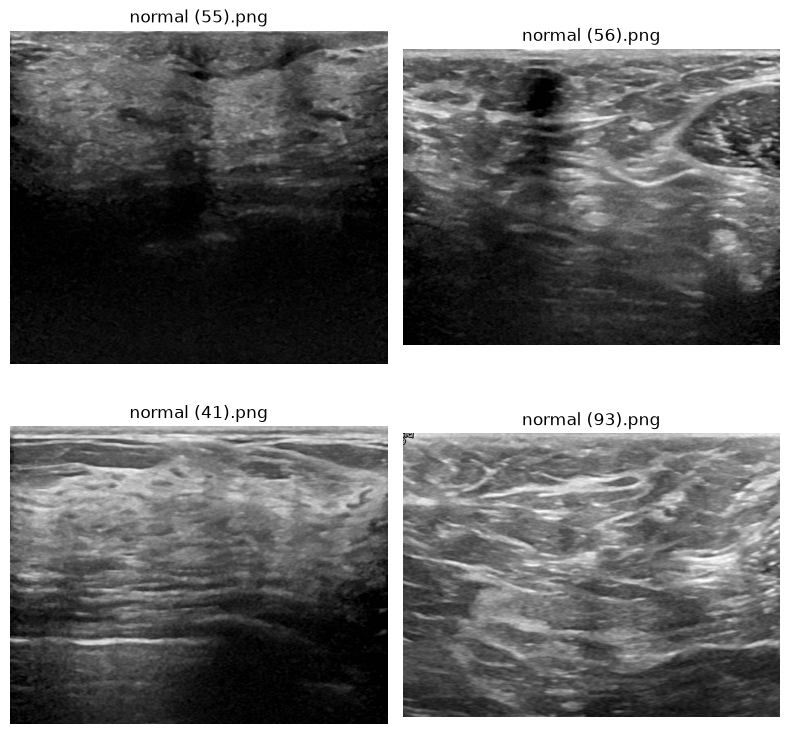


masks  for: normal :


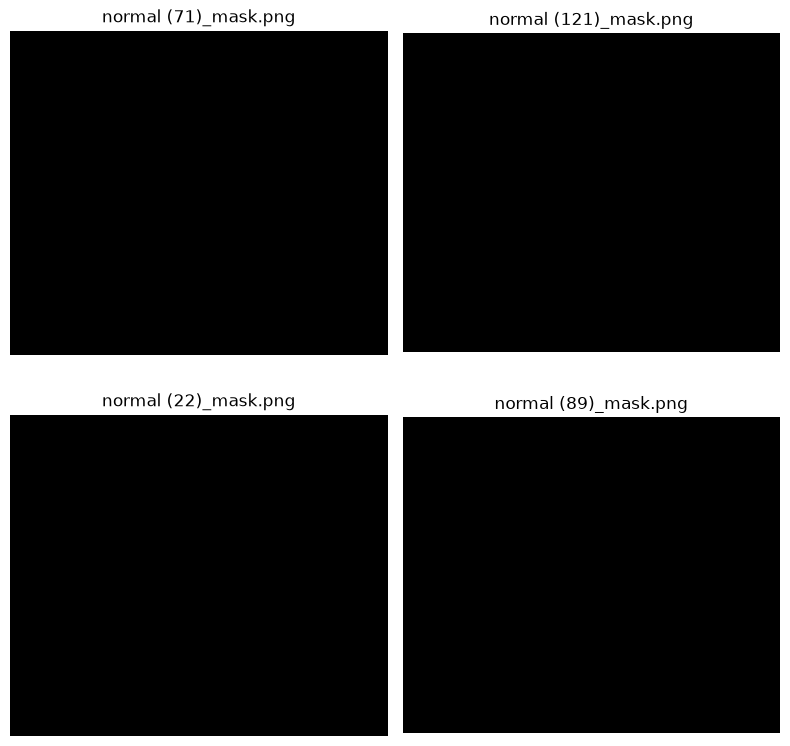


images  for: malignant :


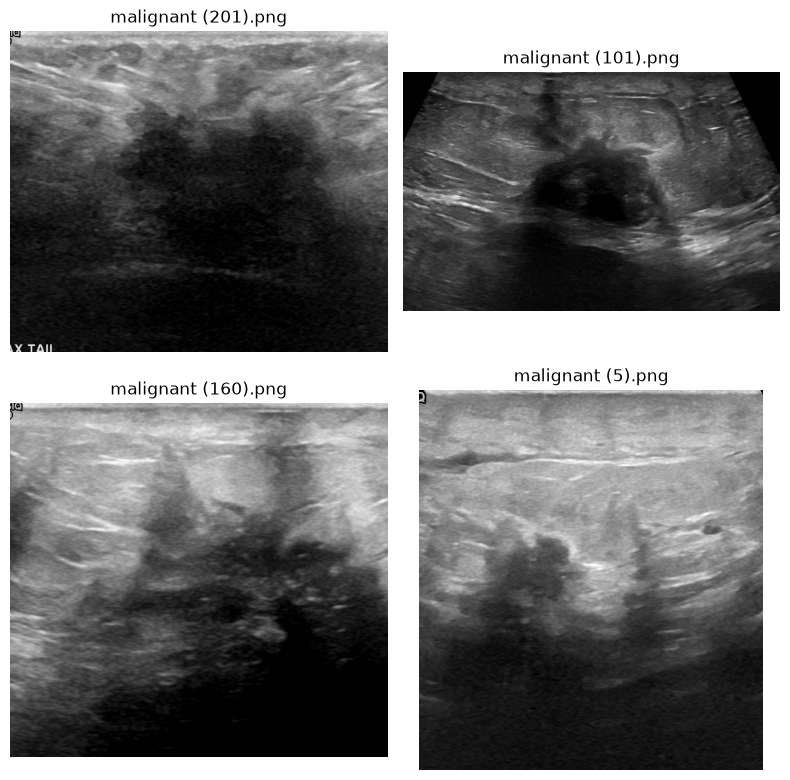


masks  for: malignant :


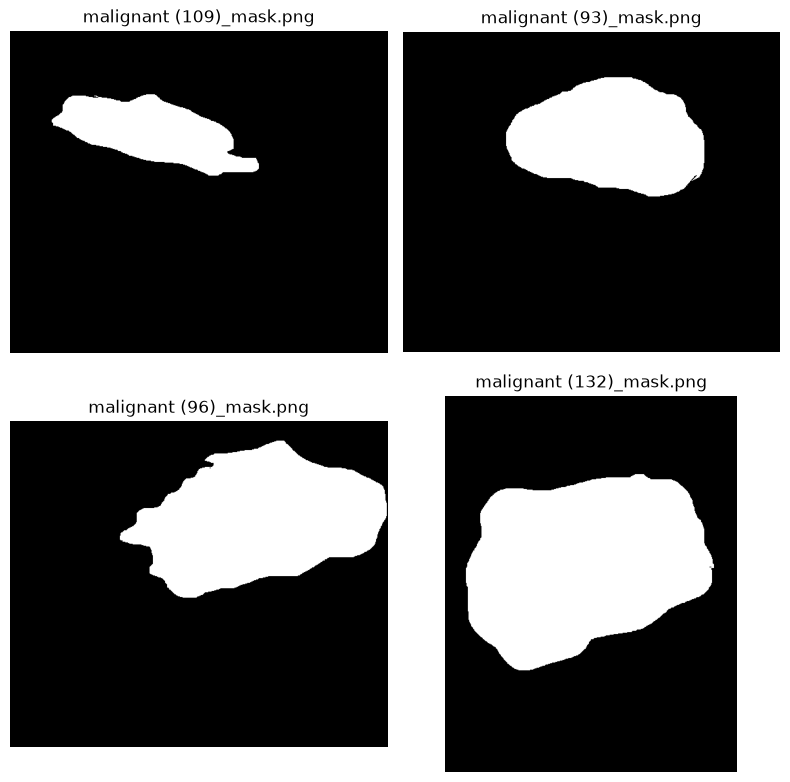

In [120]:
for key in data.keys() : 
    if key == 'brain':
        for k in data[key].keys() :
            print(k, " for:", key, ":")
            display_images([os.path.join(PATH_BRAIN_DATA, k, img) for img in data[key][k][:4]])
    else: 
        for k in data[key].keys():
            print(k, " for:", key, ":")
            display_images([os.path.join(PATH_BREAST_DATA, key, img) for img in data[key][k][:4]])

The normal masks are empty, which means they do not provide any useful segmentation information. Therefore, they should be removed from the segmentation dataset. Additionally, the brain tumor images and masks are in RGB format, as observed in the previous size analysis. Therefore, the images should be converted to grayscale, while the masks should be converted to binary format before training.


In [121]:
def display_barh(labels, values) : 
    fig, ax = plt.subplots(figsize=(8, 4))

    bars = ax.barh(labels, values)

    ax.invert_yaxis()

    # Ajouter les valeurs
    for bar in bars:
        value = bar.get_width()

        ax.text(
            value + 2,
            bar.get_y() + bar.get_height() / 2,
            str(value),
            va="center"
        )

    ax.set_xlabel("Number of Images")
    ax.set_title("Class Distribution")

    plt.tight_layout()
    plt.show()

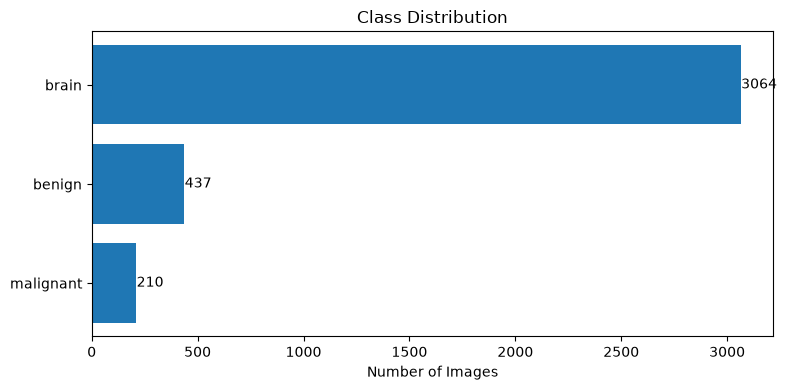

In [122]:
values = []
labels = []
for key in data.keys() : 
    if key == "normal" : 
        continue
    values.append(len(data[key]["images"]))
    labels.append(key)


display_barh(labels, values)


After plotting the bar chart, we can see that the number of Brain Tumor images (3,054) is much larger than the number of Breast Tumor images (647: 210 malignant and 437 benign). To create a balanced dataset, we can randomly select 647 Brain Tumor images while keeping all 647 Breast Tumor images.

In [123]:
def nb_masks_for_image(masks):
    nb_masks = {}
    for mask in masks : 
        img = mask.split("_mask")[0]
        nb_masks[img] =  nb_masks[img] + 1 if img in nb_masks.keys() else  1 
    for key, val in nb_masks.items() : 
        if val > 1 : 
            print(key, " : ", val)
    print("The auther images have just 1 mask") 
     


In [124]:
def valide_brain_masks(images, masks) : 
    for image in images: 
        if image not in masks: 
            print("This image '", image, "' not the mask.")
            break
    else :
        print("All images are the mask.")

In [125]:
for key in data.keys() : 
    if key == "brain" :
        print(key)
        valide_brain_masks(data["brain"]["images"], data["brain"]["masks"])
        print()
    elif key != "normal":
        print(key, ":")
        nb_masks_for_image(data[key]["masks"])
        print()
    


brain
All images are the mask.

benign :
benign (195)  :  3
benign (100)  :  2
benign (83)  :  2
benign (163)  :  2
benign (92)  :  2
benign (98)  :  2
benign (58)  :  2
benign (315)  :  2
benign (181)  :  2
benign (173)  :  2
benign (93)  :  2
benign (4)  :  2
benign (25)  :  2
benign (54)  :  2
benign (424)  :  2
benign (346)  :  2
The auther images have just 1 mask

malignant :
malignant (53)  :  2
The auther images have just 1 mask



Some Breast Tumor images have more than one corresponding mask, whereas each Brain Tumor image has only one mask. Therefore, we need to merge the multiple masks into a single mask for each Breast Tumor image before using the data for segmentation.


In [126]:
def frequency_size(paths_images) :
    sizes = []
    for path in paths_images: 
        with Image.open(path) as img: 
            sizes.append(img.size)

    size_counter = Counter(sizes)
    most_common_size = size_counter.most_common(3)
    print(most_common_size)


In [127]:
for key in data.keys(): 
    print(key, " :")
    if key != "brain" :
        frequency_size([os.path.join(PATH_BREAST_DATA, key, img) for img in data[key]["images"]])
    else: 
        frequency_size([os.path.join(PATH_BRAIN_DATA, "images", img) for img in data[key]["images"]])

    print()

brain  :
[((512, 512), 3049), ((256, 256), 15)]

benign  :
[((557, 465), 4), ((544, 469), 3), ((555, 471), 3)]

normal  :
[((763, 598), 3), ((558, 467), 3), ((562, 470), 2)]

malignant  :
[((564, 469), 3), ((557, 463), 2), ((557, 465), 2)]



The image size (512, 512) is the most frequent in the dataset. Therefore, after combining the images into a single dataset, we need to resize all images and masks to a consistent size of (512, 512).
